# Notebook 3. SASRec эксперименты

В этом ноутбуке я перехожу от простых baseline-моделей и GRU к SASRec. Эта модель использует self-attention и поэтому может учитывать не только последний трек, но и более длинный пользовательский контекст.

Основная логика ноутбука такая: сначала я собираю данные в формате последовательностей, затем обучаю несколько SASRec-кандидатов и сравниваю их по метрикам качества и свойствам рекомендательных списков. На этом этапе задача не в том, чтобы сразу получить финальную модель, а в том, чтобы понять, какие направления улучшения SASRec выглядят наиболее перспективными для дальнейшего fine-tuning.

## 1. Импорты и загрузка данных

In [ ]:
!pip install -q tqdm pyarrow

In [ ]:
import os
import json
import time
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.options.display.max_columns = 120
pd.options.display.max_rows = 120
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: cuda


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Курсовая/final_subsample"
final_events = pd.read_parquet(f"{DATA_DIR}/final_events.parquet")


final_events["timestamp"] = pd.to_numeric(final_events["timestamp"], errors="coerce")
final_events = final_events.dropna(subset=["timestamp"])
final_events["timestamp"] = final_events["timestamp"].astype("int64")
final_events["is_organic"] = final_events["is_organic"].astype(int)
final_events["played_ratio_pct"] = pd.to_numeric(final_events["played_ratio_pct"], errors="coerce")
final_events = (final_events.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values(["uid", "timestamp"]).reset_index(drop=True))

print(final_events.shape)
final_events.head()

Mounted at /content/drive
(10206636, 5)


,uid,item_id,timestamp,is_organic,played_ratio_pct
0,100,1441281,39420,0,100.0
1,100,3397170,40360,0,46.0
2,100,1449307,40640,0,100.0
3,100,2996197,40885,0,100.0
4,100,6474571,41130,0,100.0


## 2. Leave-one-out split

Для SASRec используется та же схема leave-one-out, что и для baseline-моделей. Для каждого пользователя последнее событие становится test target, предпоследнее - validation target, а все более ранние события формируют train history. Как ранееотмечалось, это важно, потому что все модели сравниваются в одинаковой постановке next-track prediction.

In [ ]:
def build_leave_one_out_split(events: pd.DataFrame, min_events: int = 3):
    df = events.sort_values(["uid", "timestamp"]).copy()
    lengths = df.groupby("uid")["item_id"].transform("size")
    df = df[lengths >= min_events].copy()

    df["pos"] = df.groupby("uid").cumcount()
    df["n_events"] = df.groupby("uid")["item_id"].transform("size")

    train = df[df["pos"] < df["n_events"] - 2].copy()
    val = df[df["pos"] == df["n_events"] - 2].copy()
    test = df[df["pos"] == df["n_events"] - 1].copy()

    return train, val, test

In [ ]:
train_events, val_events, test_events = build_leave_one_out_split(final_events, min_events=3)

# оставляем только warm-start users/items
train_users = set(train_events["uid"].unique())
train_items = set(train_events["item_id"].unique())

In [ ]:
# оставляем валидацию только для пользователей, которые остались в тесте
val_events = val_events[val_events["uid"].isin(train_users) & val_events["item_id"].isin(train_items)].copy()
valid_val_users = set(val_events["uid"].unique())
test_events = test_events[test_events["uid"].isin(valid_val_users) & test_events["item_id"].isin(train_items)].copy()

In [ ]:
test_users = set(test_events["uid"].unique())
val_events = val_events[val_events["uid"].isin(test_users)].copy()
train_events_eval = train_events[train_events["uid"].isin(test_users)].copy()

In [ ]:
split_summary = pd.DataFrame({
    "part": ["train_events", "validation_targets", "test_targets"],
    "rows": [len(train_events_eval), len(val_events), len(test_events)],
    "users": [
        train_events_eval["uid"].nunique(),
        val_events["uid"].nunique(),
        test_events["uid"].nunique()
    ],
    "items": [
        train_events_eval["item_id"].nunique(),
        val_events["item_id"].nunique(),
        test_events["item_id"].nunique()]})

split_summary

,part,rows,users,items
0,train_events,10196170,4973,299841
1,validation_targets,4973,4973,3806
2,test_targets,4973,4973,3846


## 3. Sequence dataset

SASRec работает с последовательностями, поэтому перед обучением нужно перевести реальные item_id во внутренние индексы модели и привести пользовательские истории к фиксированной длине.

В базовом варианте я ограничиваю число обучающих состояний на пользователя. Это ускоряет первые эксперименты и позволяет быстрее сравнить несколько конфигураций модели.

In [ ]:
MAX_LEN = 100
MAX_TRAIN_SAMPLES_PER_USER = 20
BATCH_SIZE = 128

# перевожу реальные item_id во внутренние индексы модели
item_ids = train_events_eval["item_id"].drop_duplicates().tolist()
item2idx = {item_id: idx + 1 for idx, item_id in enumerate(item_ids)}
idx2item = {idx: item_id for item_id, idx in item2idx.items()}
num_items = len(item2idx) + 1

print("num_items:", num_items)
print("MAX_LEN:", MAX_LEN)
print("MAX_TRAIN_SAMPLES_PER_USER:", MAX_TRAIN_SAMPLES_PER_USER)

num_items: 299842
MAX_LEN: 100
MAX_TRAIN_SAMPLES_PER_USER: 20


In [ ]:
def pad_sequence(seq, max_len, pad_value=0):
    seq = seq[-max_len:]
    return [pad_value] * (max_len - len(seq)) + seq

In [ ]:
def build_sequence_samples(train_events_eval, val_events, test_events, item2idx, max_len=100, max_train_samples_per_user=20):
    train_encoded = train_events_eval.sort_values(["uid", "timestamp"]).copy()
    train_encoded["item_idx"] = train_encoded["item_id"].map(item2idx)

    val_encoded = val_events[val_events["item_id"].isin(item2idx)].copy()
    val_encoded["target_idx"] = val_encoded["item_id"].map(item2idx).astype(int)

    test_encoded = test_events[test_events["item_id"].isin(item2idx)].copy()
    test_encoded["target_idx"] = test_encoded["item_id"].map(item2idx).astype(int)

    user_train_seq = train_encoded.groupby("uid")["item_idx"].apply(list).to_dict()
    user_val_target = dict(zip(val_encoded["uid"], val_encoded["target_idx"]))
    user_test_target = dict(zip(test_encoded["uid"], test_encoded["target_idx"]))

    train_samples, val_samples, test_samples = [], [], []

    for uid, seq in user_train_seq.items():
        if len(seq) >= 2:
            start_i = max(1, len(seq) - max_train_samples_per_user)
            for i in range(start_i, len(seq)):
                train_samples.append({
                    "uid": uid,
                    "input_seq": pad_sequence(seq[:i], max_len),
                    "target": seq[i]
                })

        if uid in user_val_target and len(seq) >= 1:
            val_samples.append({
                "uid": uid,
                "input_seq": pad_sequence(seq, max_len),
                "target": user_val_target[uid]
            })

        if uid in user_test_target and uid in user_val_target and len(seq) >= 1:
            test_input = seq + [user_val_target[uid]]
            test_samples.append({
                "uid": uid,
                "input_seq": pad_sequence(test_input, max_len),
                "target": user_test_target[uid]
            })

    return pd.DataFrame(train_samples), pd.DataFrame(val_samples), pd.DataFrame(test_samples)


In [ ]:
train_df, val_df, test_df = build_sequence_samples(
    train_events_eval=train_events_eval,
    val_events=val_events,
    test_events=test_events,
    item2idx=item2idx,
    max_len=MAX_LEN,
    max_train_samples_per_user=MAX_TRAIN_SAMPLES_PER_USER
)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (97898, 3)
val_df: (4973, 3)
test_df: (4973, 3)


In [ ]:
class SeqRecDataset(Dataset):
    def __init__(self, df):
        self.inputs = df["input_seq"].tolist()
        self.targets = df["target"].tolist()

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long))

In [ ]:
train_loader = DataLoader(SeqRecDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SeqRecDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SeqRecDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 765
val batches: 39
test batches: 39


## 4. Метрики и функции обучения

В этом разделе задаются функции для обучения и оценки SASRec-кандидатов. Качество модели оценивается по ranking-метрикам: Recall, Precision, NDCG и MRR.

Дополнительно считаются метрики свойств выдачи: coverage, число уникальных рекомендованных треков, Gini. Это нужно, чтобы сравнивать модели не только по попаданию в target, но и по тому, насколько широко они покрывают каталог.

In [ ]:
def recall_at_k(logits, targets, k):
    topk = torch.topk(logits, k=k, dim=1).indices
    return (topk == targets.unsqueeze(1)).any(dim=1).float().sum().item()

In [ ]:
def ranking_sums_at_k(logits, targets, k):
    topk = torch.topk(logits, k=k, dim=1).indices

    hits = 0.0
    ndcg_sum = 0.0
    mrr_sum = 0.0

    for i in range(targets.size(0)):
        preds = topk[i].tolist()
        target = targets[i].item()

        if target in preds:
            rank = preds.index(target) + 1
            hits += 1.0
            ndcg_sum += 1.0 / np.log2(rank + 1)
            mrr_sum += 1.0 / rank

    return hits, ndcg_sum, mrr_sum

In [ ]:
@torch.no_grad()
def evaluate_full_softmax(model, loader, ks=(10, 50)):
    model.eval()

    total = 0
    hits = {k: 0.0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    mrrs = {k: 0.0 for k in ks}

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        if logits.size(1) > 0:
            logits[:, 0] = -1e9

        total += y.size(0)

        for k in ks:
            batch_hits, batch_ndcg, batch_mrr = ranking_sums_at_k(logits, y, k)
            hits[k] += batch_hits
            ndcgs[k] += batch_ndcg
            mrrs[k] += batch_mrr

    out = {}
    for k in ks:
        recall = hits[k] / max(1, total)
        out[f"Recall@{k}"] = recall
        out[f"Precision@{k}"] = recall / k
        out[f"NDCG@{k}"] = ndcgs[k] / max(1, total)
        out[f"MRR@{k}"] = mrrs[k] / max(1, total)

    return out

In [ ]:
def train_one_epoch_full_softmax(model, loader, optimizer, criterion, max_batches=None):
    model.train()

    loss_sum = 0.0
    used_batches = 0
    start = time.time()

    for batch_idx, (x, y) in enumerate(tqdm(loader, leave=False)):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        used_batches += 1

    return loss_sum / max(1, used_batches), time.time() - start, used_batches

### Метрики покрытия, разнообразия и popularity bias

Эти метрики считаются по спискам top-K рекомендаций и нужны для сравнения SASRec-кандидатов не только по качеству попадания в target, но и по широте покрытия каталога и концентрации на популярных треках.


In [ ]:
def build_popularity_reference(train_events_eval: pd.DataFrame):

    item_pop_df = (train_events_eval.groupby("item_id").size().rename("train_popularity").reset_index())
    item_pop_df["log_popularity"] = np.log1p(item_pop_df["train_popularity"])
    item_pop_df["popularity_bin"] = pd.qcut(item_pop_df["log_popularity"].rank(method="first"), q=10, labels=False,duplicates="drop").astype(int)

    popularity_bin_map = dict(zip(item_pop_df["item_id"], item_pop_df["popularity_bin"]))
    item_universe = train_events_eval["item_id"].unique()

    return item_pop_df, popularity_bin_map, item_universe

In [ ]:
def gini_from_counts(counts):
    values = np.array(list(counts), dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cum_values = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cum_values) / cum_values[-1]) / n

In [ ]:
def flatten_recommendations(recs: dict, k: int):
    flat = []

    for items in recs.values():
        flat.extend(items[:k])

    return flat

In [ ]:
def recommendation_exposure_metrics(recs: dict, experiment_name: str, item_universe, popularity_bin_map: dict, ks=(10, 50)):
    rows = []
    catalog_size = len(set(item_universe))

    for k in ks:
        flat_recs = flatten_recommendations(recs, k=k)

        if len(flat_recs) == 0:
            rows.append({
                "experiment": experiment_name,
                "K": k,
                "Unique Recommended Items@K": 0,
                "Catalog Coverage@K": 0.0,
                "Gini@K": np.nan

            })
            continue

        rec_counts = pd.Series(flat_recs).value_counts()
        unique_recs = int(rec_counts.shape[0])


        rows.append({
            "experiment": experiment_name,
            "K": k,
            "Unique Recommended Items@K": unique_recs,
            "Catalog Coverage@K": unique_recs / max(1, catalog_size),
            "Gini@K": gini_from_counts(rec_counts.values),

        })

    return pd.DataFrame(rows)

In [ ]:
@torch.no_grad()
def generate_sasrec_recommendations(
    model,
    loader,
    eval_df: pd.DataFrame,
    idx2item: dict,
    top_k=50,
    sampled_model=False
):
    model.eval()

    recs = {}
    eval_users = eval_df["uid"].tolist()
    pointer = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)

        if sampled_model:
            logits = model.full_logits(x)
        else:
            logits = model(x)

        if logits.size(1) > 0:
            logits[:, 0] = -1e9

        topk = torch.topk(logits, k=top_k, dim=1).indices.cpu().numpy()

        for pred_idxs in topk:
            uid = eval_users[pointer]
            recs[uid] = [
                idx2item[int(idx)]
                for idx in pred_idxs
                if int(idx) in idx2item
            ]
            pointer += 1

    return recs


item_pop_df, popularity_bin_map, item_universe = build_popularity_reference(train_events_eval)
item_pop_df.head()

,item_id,train_popularity,log_popularity,popularity_bin
0,81,1,0.693147,0
1,127,2,1.098612,3
2,142,1,0.693147,0
3,167,2,1.098612,3
4,206,412,6.023448,9


## 5. Архитектура SASRec


В этом блоке задаётся архитектура SASRec. В отличие от GRU, которая обрабатывает последовательность рекуррентно, SASRec использует self-attention: для каждого элемента истории модель может учитывать другие элементы последовательности и выделять наиболее важные предыдущие взаимодействия.

Модель состоит из нескольких основных частей:

1. item_embedding - переводит id трека во внутреннее векторное представление
2. position_embedding - добавляет информацию о позиции трека в последовательности
3. TransformerEncoder - обрабатывает последовательность с causal mask, чтобы модель не видела будущие элементы
4. LayerNorm и Dropout - стабилизируют обучение и уменьшают переобучение
5. Linear слой - переводит итоговое скрытое состояние в scores по всем item.

Для предсказания следующего трека используется скрытое состояние последнего непустого элемента последовательности. Это состояние интерпретируется как сжатое представление текущего пользовательского контекста.

In [ ]:
# базовая реализация SASRec для next-item prediction
class SASRec(nn.Module):
    def __init__(
        self,
        num_items,
        max_len,
        hidden_dim=128,
        num_heads=2,
        num_layers=1,
        dropout=0.2,
        padding_idx=0
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.padding_idx = padding_idx

        self.item_embedding = nn.Embedding(num_items, hidden_dim, padding_idx=padding_idx)
        self.position_embedding = nn.Embedding(max_len, hidden_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)
        self.output = nn.Linear(hidden_dim, num_items)

    def encode(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        h = self.item_embedding(x) + self.position_embedding(positions)
        h = self.dropout(h)

        padding_mask = x.eq(self.padding_idx)
        # causal mask не даёт модели смотреть в будущие позиции
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)

        h = self.encoder(h, mask=causal_mask, src_key_padding_mask=padding_mask)
        h = self.norm(h)

        lengths = (~padding_mask).sum(dim=1).clamp(min=1)
        last_idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_dim)
        last_hidden = h.gather(dim=1, index=last_idx).squeeze(1)

        return last_hidden

    def forward(self, x):
        return self.output(self.encode(x))

In [ ]:
def run_sasrec_full_softmax_experiment(config, max_batches_per_epoch=None):
    model = SASRec(
        num_items=num_items,
        max_len=MAX_LEN,
        hidden_dim=config["hidden_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0)
    )
    criterion = nn.CrossEntropyLoss()

    best_state = None
    # лучшее состояние выбирается по validation Recall@50
    best_val_recall50 = -1
    history = []

    for epoch in range(config["epochs"]):
        train_loss, epoch_time, used_batches = train_one_epoch_full_softmax(
            model, train_loader, optimizer, criterion, max_batches=max_batches_per_epoch
        )
        val_metrics = evaluate_full_softmax(model, val_loader, ks=(10, 50))

        row = {
            "experiment": config["name"],
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "epoch_time_sec": epoch_time,
            "used_batches": used_batches,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(row)

        if val_metrics["Recall@50"] > best_val_recall50:
            best_val_recall50 = val_metrics["Recall@50"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"\n{config['name']} | epoch {epoch + 1}/{config['epochs']}")
        print(f"train loss: {train_loss:.4f}")
        print(f"time sec: {epoch_time:.2f}")
        print("val:", val_metrics)

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_full_softmax(model, test_loader, ks=(10, 50))

    result = {
        "experiment": config["name"],
        "model": "SASRec",
        "training_type": "full_softmax",
        "hidden_dim": config["hidden_dim"],
        "num_heads": config["num_heads"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config.get("weight_decay", 0.0),
        "epochs": config["epochs"],
        "best_val_Recall@50": best_val_recall50,
        **test_metrics
    }

    return model, pd.DataFrame(history), result

## 6. Эксперимент 1: базовый SASRec

Первый запуск нужен как стартовая точка. Здесь используется компактная SASRec-конфигурация с full softmax обучением по всему словарю треков. Цель этого эксперимента заключается в том, чтобы проверить, что self-attention модель обучается в нашей постановке и даёт осмысленное качество на validation и test.

In [ ]:
sasrec_base_config = {
    "name": "sasrec_base",
    "hidden_dim": 128,
    "num_heads": 2,
    "num_layers": 1,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 0.0,
    "epochs": 3,
}

sasrec_base_model, sasrec_base_history, sasrec_base_result = run_sasrec_full_softmax_experiment(sasrec_base_config, max_batches_per_epoch=None)
sasrec_base_result

/tmp/ipykernel_3256/164580333.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_base | epoch 1/3
train loss: 10.7292
time sec: 10.90
val: {'Recall@10': 0.016086869093102755, 'Precision@10': 0.0016086869093102755, 'NDCG@10': np.float64(0.007371968407968197), 'MRR@10': 0.004754483735983837, 'Recall@50': 0.05087472350693746, 'Precision@50': 0.0010174944701387492, 'NDCG@50': np.float64(0.014774021703885993), 'MRR@50': 0.006193865845942607}


  0%|          | 0/765 [00:00<?, ?it/s]

...

  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_base | epoch 3/3
train loss: 8.3331
time sec: 9.84
val: {'Recall@10': 0.06334204705409209, 'Precision@10': 0.006334204705409209, 'NDCG@10': np.float64(0.047234042326886064), 'MRR@10': 0.04224742179196231, 'Recall@50': 0.10134727528654736, 'Precision@50': 0.002026945505730947, 'NDCG@50': np.float64(0.05546214305103805), 'MRR@50': 0.04392081773484302}


  0%|          | 0/39 [00:00<?, ?it/s]

{'experiment': 'sasrec_base',
 'model': 'SASRec',
 'training_type': 'full_softmax',
 'hidden_dim': 128,
 'num_heads': 2,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.001,
 'weight_decay': 0.0,
 'epochs': 3,
 'best_val_Recall@50': 0.10134727528654736,
 'Recall@10': 0.06877136537301427,
 'Precision@10': 0.006877136537301427,
 'NDCG@10': np.float64(0.0515269397146767),
 'MRR@10': 0.046149524894749105,
 'Recall@50': 0.10657550774180576,
 'Precision@50': 0.002131510154836115,
 'NDCG@50': np.float64(0.05952473087081612),
 'MRR@50': 0.04770825242281033}

**Вывод:** Базовый SASRec показывает рост validation-метрик по эпохам: train loss снижается, а Recall@50 и NDCG@50 увеличиваются. Это подтверждает, что модель извлекает сигнал из последовательностей пользователей. При этом качество пока не является финальным, так как модель обучалась только 3 эпохи и использовалась как стартовый benchmark для следующих экспериментов.

## 7. Эксперимент 2: усиленный SASRec

Во втором эксперименте проверяется более сильная конфигурация SASRec. По сравнению с базовой моделью увеличивается число attention heads и Transformer layers. Такой вариант должен лучше улавливать зависимости внутри пользовательской истории, но при этом он может быть тяжелее в обучении и сильнее концентрироваться на наиболее частых паттернах.

In [ ]:
sasrec_stronger_config = {
    "name": "sasrec_stronger",
    "hidden_dim": 128,
    "num_heads": 4,
    "num_layers": 2,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 3,
}

sasrec_stronger_model, sasrec_stronger_history, sasrec_stronger_result = run_sasrec_full_softmax_experiment(sasrec_stronger_config, max_batches_per_epoch=None)
sasrec_stronger_result

/tmp/ipykernel_3256/164580333.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_stronger | epoch 1/3
train loss: 10.6540
time sec: 12.27
val: {'Recall@10': 0.015684697365775185, 'Precision@10': 0.0015684697365775184, 'NDCG@10': np.float64(0.00764272356933646), 'MRR@10': 0.005257996354919742, 'Recall@50': 0.051075809370601244, 'Precision@50': 0.0010215161874120248, 'NDCG@50': np.float64(0.014997006186789022), 'MRR@50': 0.0066102345925384085}


  0%|          | 0/765 [00:00<?, ?it/s]

...

  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_stronger | epoch 3/3
train loss: 8.3604
time sec: 12.23
val: {'Recall@10': 0.06676050673637643, 'Precision@10': 0.006676050673637643, 'NDCG@10': np.float64(0.04853140671579183), 'MRR@10': 0.042793545462960304, 'Recall@50': 0.1150211140156847, 'Precision@50': 0.002300422280313694, 'NDCG@50': np.float64(0.058912871268386686), 'MRR@50': 0.04487484749095026}


  0%|          | 0/39 [00:00<?, ?it/s]

{'experiment': 'sasrec_stronger',
 'model': 'SASRec',
 'training_type': 'full_softmax',
 'hidden_dim': 128,
 'num_heads': 4,
 'num_layers': 2,
 'dropout': 0.2,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'epochs': 3,
 'best_val_Recall@50': 0.1150211140156847,
 'Recall@10': 0.06756485019103158,
 'Precision@10': 0.006756485019103158,
 'NDCG@10': np.float64(0.04755739844112871),
 'MRR@10': 0.04138634339720203,
 'Recall@50': 0.11019505328775388,
 'Precision@50': 0.0022039010657550775,
 'NDCG@50': np.float64(0.05671424457825823),
 'MRR@50': 0.043228397563389045}

**Вывод:** Усиленная SASRec-конфигурация показывает более высокое качество по сравнению с базовой моделью. Это говорит о том, что увеличение числа attention heads и Transformer layers помогает модели лучше использовать последовательный контекст. Однако эксперимент всё ещё является предварительным: для честного выбора финальной модели нужно сравнить несколько направлений улучшения и обучать лучшие варианты дольше.

## 8. Эксперимент 3: SASRec с negative sampling

В этом эксперименте проверяется альтернативная схема обучения. Вместо сравнения target item со всем каталогом модель учится отличать правильный следующий трек от набора случайно выбранных negative items. Такой подход может ускорять обучение на больших каталогах, но качество сильно зависит от числа negative samples и способа их выбора.

In [ ]:
class SASRecSampled(nn.Module):
    def __init__(
        self,
        num_items,
        max_len,
        hidden_dim=128,
        num_heads=2,
        num_layers=1,
        dropout=0.2,
        padding_idx=0
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.padding_idx = padding_idx

        self.item_embedding = nn.Embedding(num_items, hidden_dim, padding_idx=padding_idx)
        self.position_embedding = nn.Embedding(max_len, hidden_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def encode(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        h = self.item_embedding(x) + self.position_embedding(positions)
        h = self.dropout(h)

        padding_mask = x.eq(self.padding_idx)
        # causal mask не даёт модели смотреть в будущие позиции
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        h = self.encoder(h, mask=causal_mask, src_key_padding_mask=padding_mask)
        h = self.norm(h)

        lengths = (~padding_mask).sum(dim=1).clamp(min=1)
        last_idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_dim)
        return h.gather(dim=1, index=last_idx).squeeze(1)

    def score_items(self, user_repr, item_idx):
        item_emb = self.item_embedding(item_idx)
        return (user_repr.unsqueeze(1) * item_emb).sum(dim=-1)

    def full_logits(self, x):
        user_repr = self.encode(x)
        return user_repr @ self.item_embedding.weight.T

На следующем шаге задаются функции для negative sampling. Для каждого target item случайно выбираются отрицательные треки, которые не совпадают с положительным примером. Затем модель обучается через бинарную классификацию: positive item получает лэйбл 1, а negative items это лэйбл 0.

In [ ]:
def sample_negative_items(batch_size, num_negatives, num_items, positive_items, device):
    negatives = torch.randint(1, num_items, (batch_size, num_negatives), device=device)
    positives = positive_items.unsqueeze(1)

    mask = negatives.eq(positives)
    while mask.any():
        negatives[mask] = torch.randint(1, num_items, (int(mask.sum().item()),), device=device)
        mask = negatives.eq(positives)

    return negatives

In [ ]:
def train_one_epoch_sampled(model, loader, optimizer, num_items, num_negatives=100, max_batches=None):
    model.train()
    bce = nn.BCEWithLogitsLoss()

    loss_sum = 0.0
    used_batches = 0
    start = time.time()

    for batch_idx, (x, y) in enumerate(tqdm(loader, leave=False)):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        batch_size = y.size(0)

        negatives = sample_negative_items(batch_size, num_negatives, num_items, y, device)

        optimizer.zero_grad()
        user_repr = model.encode(x)

        pos_scores = model.score_items(user_repr, y.unsqueeze(1)).squeeze(1)
        neg_scores = model.score_items(user_repr, negatives)

        scores = torch.cat([pos_scores.unsqueeze(1), neg_scores], dim=1)
        labels = torch.zeros_like(scores)
        labels[:, 0] = 1.0

        loss = bce(scores, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        used_batches += 1

    return loss_sum / max(1, used_batches), time.time() - start, used_batches

In [ ]:
@torch.no_grad()
def evaluate_sampled_full_ranking(model, loader, ks=(10, 50)):
    model.eval()

    total = 0
    hits = {k: 0.0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    mrrs = {k: 0.0 for k in ks}

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model.full_logits(x)
        if logits.size(1) > 0:
            logits[:, 0] = -1e9

        total += y.size(0)

        for k in ks:
            batch_hits, batch_ndcg, batch_mrr = ranking_sums_at_k(logits, y, k)
            hits[k] += batch_hits
            ndcgs[k] += batch_ndcg
            mrrs[k] += batch_mrr

    out = {}
    for k in ks:
        recall = hits[k] / max(1, total)
        out[f"Recall@{k}"] = recall
        out[f"Precision@{k}"] = recall / k
        out[f"NDCG@{k}"] = ndcgs[k] / max(1, total)
        out[f"MRR@{k}"] = mrrs[k] / max(1, total)

    return out

Далее задаётся полный цикл запуска SASRec с negative sampling. Он аналогичен full-softmax экспериментам: модель обучается несколько эпох, после каждой эпохи считается validation quality, лучшая версия выбирается по Recall@50, а затем оценивается на test.

In [ ]:
def run_sasrec_sampled_experiment(config, max_batches_per_epoch=None):
    model = SASRecSampled(
        num_items=num_items,
        max_len=MAX_LEN,
        hidden_dim=config["hidden_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0)
    )

    best_state = None
    best_val_recall50 = -1
    history = []

    for epoch in range(config["epochs"]):
        train_loss, epoch_time, used_batches = train_one_epoch_sampled(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            num_items=num_items,
            num_negatives=config["num_negatives"],
            max_batches=max_batches_per_epoch
        )

        val_metrics = evaluate_sampled_full_ranking(model, val_loader, ks=(10, 50))

        row = {
            "experiment": config["name"],
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "epoch_time_sec": epoch_time,
            "used_batches": used_batches,
            "num_negatives": config["num_negatives"],
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(row)

        if val_metrics["Recall@50"] > best_val_recall50:
            best_val_recall50 = val_metrics["Recall@50"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"\n{config['name']} | epoch {epoch + 1}/{config['epochs']}")
        print(f"train loss: {train_loss:.4f}")
        print(f"time sec: {epoch_time:.2f}")
        print("val:", val_metrics)

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_sampled_full_ranking(model, test_loader, ks=(10, 50))

    result = {
        "experiment": config["name"],
        "model": "SASRec",
        "training_type": "sampled_negative",
        "hidden_dim": config["hidden_dim"],
        "num_heads": config["num_heads"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config.get("weight_decay", 0.0),
        "epochs": config["epochs"],
        "num_negatives": config["num_negatives"],
        "best_val_Recall@50": best_val_recall50,
        **test_metrics
    }

    return model, pd.DataFrame(history), result

## 9. Эксперимент 3: SASRec с negative sampling

В этом эксперименте проверяется SASRec с обучением через negative sampling. В отличие от full softmax, модель на каждом шаге сравнивает правильный следующий трек не со всем каталогом, а с ограниченным числом случайно выбранных negative items.

Такой подход обычно используется для ускорения обучения на больших item-каталогах. Однако его качество может сильно зависеть от числа negative samples и способа их выбора.

In [ ]:
sasrec_sampled_config = {
    "name": "sasrec_sampled_100neg",
    "hidden_dim": 128,
    "num_heads": 2,
    "num_layers": 1,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 3,
    "num_negatives": 100,
}

sasrec_sampled_model, sasrec_sampled_history, sasrec_sampled_result = run_sasrec_sampled_experiment(sasrec_sampled_config, max_batches_per_epoch=None)
sasrec_sampled_result

/tmp/ipykernel_3256/2374233301.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_sampled_100neg | epoch 1/3
train loss: 1.7076
time sec: 8.06
val: {'Recall@10': 0.0016086869093102755, 'Precision@10': 0.00016086869093102755, 'NDCG@10': np.float64(0.0009670281394864304), 'MRR@10': 0.0007680362848269545, 'Recall@50': 0.004423889000603257, 'Precision@50': 8.847778001206515e-05, 'NDCG@50': np.float64(0.001502215188512561), 'MRR@50': 0.0008322121879279724}


  0%|          | 0/765 [00:00<?, ?it/s]

...

  0%|          | 0/765 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_sampled_100neg | epoch 3/3
train loss: 0.1051
time sec: 7.87
val: {'Recall@10': 0.011059722501508143, 'Precision@10': 0.0011059722501508143, 'NDCG@10': np.float64(0.004420632782749316), 'MRR@10': 0.0024703238759140626, 'Recall@50': 0.05087472350693746, 'Precision@50': 0.0010174944701387492, 'NDCG@50': np.float64(0.012918751724747957), 'MRR@50': 0.004146747231275191}


  0%|          | 0/39 [00:00<?, ?it/s]

{'experiment': 'sasrec_sampled_100neg',
 'model': 'SASRec',
 'training_type': 'sampled_negative',
 'hidden_dim': 128,
 'num_heads': 2,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'epochs': 3,
 'num_negatives': 100,
 'best_val_Recall@50': 0.05087472350693746,
 'Recall@10': 0.012869495274482204,
 'Precision@10': 0.0012869495274482204,
 'NDCG@10': np.float64(0.005137134220551481),
 'MRR@10': 0.0029019403189924,
 'Recall@50': 0.054695354916549366,
 'Precision@50': 0.0010939070983309873,
 'NDCG@50': np.float64(0.013951687637462388),
 'MRR@50': 0.0045933061582177645}

**Вывод:** SASRec с negative sampling в текущей конфигурации показывает заметно более слабое качество, чем full-softmax варианты. При num_negatives = 100 модель получает Recall@50 около 0.055, тогда как базовый SASRec и усиленный SASRec дают более высокие значения. Также у sampled-модели существенно ниже coverage: она рекомендует намного меньше уникальных треков и сильнее концентрируется на ограниченном наборе items. Поэтому в дальнейшем negative sampling не выбирается как основная ветка, а остаётся как дополнительный эксперимент.

## 10. Результаты SASRec-экспериментов

В этом разделе SASRec-кандидаты сравниваются по двум группам метрик. Первая группа оценивает качество предсказания следующего трека: Recall@K, Precision@K, NDCG@K и MRR@K. Вторая группа описывает свойства рекомендательных списков: coverage, число уникальных рекомендованных треков и концентрацию рекомендаций.

Основной горизонт сравнения - @50, так как для музыкальных рекомендаций top-50 лучше отражает практический сценарий выдачи списка треков.

In [ ]:
sasrec_accuracy_results_long = pd.DataFrame([sasrec_base_result, sasrec_stronger_result, sasrec_sampled_result, *tuning_results])
sasrec_accuracy_results_long.sort_values("Recall@50", ascending=False)

,experiment,model,training_type,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,epochs,best_val_Recall@50,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@50,Precision@50,NDCG@50,MRR@50,num_negatives
1,sasrec_stronger,SASRec,full_softmax,128,4,2,0.2,0.001,0.00001,3,0.115021,0.067565,0.006756,0.047557,0.041386,0.110195,0.002204,0.056714,0.043228,NaN
0,sasrec_base,SASRec,full_softmax,128,2,1,0.2,0.001,0.00000,3,0.101347,0.068771,0.006877,0.051527,0.046150,0.106576,0.002132,0.059525,0.047708,NaN
2,sasrec_sampled_100neg,SASRec,sampled_negative,128,2,1,0.2,0.001,0.00001,3,0.050875,0.012869,0.001287,0.005137,0.002902,0.054695,0.001094,0.013952,0.004593,100.0


**Вывод:** Лучшее качество по Recall@50 показывает sasrec_stronger: он немного превосходит базовый SASRec. Это говорит о том, что увеличение числа attention heads и Transformer layers помогает модели лучше использовать последовательный контекст. При этом базовый SASRec остаётся близким по NDCG@50 и MRR@50, поэтому разница между двумя full-softmax вариантами не является радикальной. Модель с negative sampling заметно уступает обоим full-softmax вариантам.

In [ ]:
sasrec_recommendations = {
    "sasrec_base": generate_sasrec_recommendations(
        sasrec_base_model,
        test_loader,
        test_df,
        idx2item,
        top_k=50,
        sampled_model=False
    ),
    "sasrec_stronger": generate_sasrec_recommendations(
        sasrec_stronger_model,
        test_loader,
        test_df,
        idx2item,
        top_k=50,
        sampled_model=False
    ),
    "sasrec_sampled_100neg": generate_sasrec_recommendations(
        sasrec_sampled_model,
        test_loader,
        test_df,
        idx2item,
        top_k=50,
        sampled_model=True
    ),
}

if len(tuning_models) > 0:
    for exp_name, model in tuning_models.items():
        sasrec_recommendations[exp_name] = generate_sasrec_recommendations(
            model,
            test_loader,
            test_df,
            idx2item,
            top_k=50,
            sampled_model=False
        )

sasrec_property_results = pd.concat(
    [
        recommendation_exposure_metrics(
            recs,
            experiment_name=exp_name,
            item_universe=item_universe,
            popularity_bin_map=popularity_bin_map,
            ks=(10, 50)
        )
        for exp_name, recs in sasrec_recommendations.items()
    ],
    ignore_index=True
)

sasrec_property_results

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

,experiment,K,Unique Recommended Items@K,Catalog Coverage@K,Gini@K
0,sasrec_base,10,6942,0.023152,0.763039
1,sasrec_base,50,14893,0.049670,0.829227
2,sasrec_stronger,10,5716,0.019063,0.781180
3,sasrec_stronger,50,12601,0.042026,0.828974
4,sasrec_sampled_100neg,10,117,0.000390,0.894259
5,sasrec_sampled_100neg,50,764,0.002548,0.912634


 **Вывод:**  На @50 усиленный SASRec показывает максимальный Recall, тогда как базовый SASRec немного лучше по NDCG и MRR. Это означает, что sasrec_stronger чаще включает правильный трек в top-50, но базовая модель иногда располагает найденный target выше в списке. Для дальнейшего fine-tuning выбирается направление full-softmax SASRec, так как оба full-softmax варианта заметно сильнее negative sampling.

In [ ]:
sasrec_results_long = sasrec_accuracy_results_long.merge(sasrec_property_results, on=["experiment"], how="left")
accuracy_long_parts = []

for _, row in sasrec_accuracy_results_long.iterrows():
    for k in (10, 50):
        accuracy_long_parts.append({
            "experiment": row["experiment"],
            "model": row["model"],
            "training_type": row["training_type"],
            "hidden_dim": row["hidden_dim"],
            "num_heads": row["num_heads"],
            "num_layers": row["num_layers"],
            "dropout": row["dropout"],
            "lr": row["lr"],
            "weight_decay": row["weight_decay"],
            "epochs": row["epochs"],
            "best_val_Recall@50": row["best_val_Recall@50"],
            "K": k,
            "Recall@K": row[f"Recall@{k}"],
            "Precision@K": row[f"Precision@{k}"],
            "NDCG@K": row[f"NDCG@{k}"],
            "MRR@K": row[f"MRR@{k}"],
        })

sasrec_accuracy_long = pd.DataFrame(accuracy_long_parts)
sasrec_results_long = sasrec_accuracy_long.merge(sasrec_property_results, on=["experiment", "K"], how="left")
sasrec_results_long

,experiment,model,training_type,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,epochs,best_val_Recall@50,K,Recall@K,Precision@K,NDCG@K,MRR@K,Unique Recommended Items@K,Catalog Coverage@K,Gini@K
0,sasrec_base,SASRec,full_softmax,128,2,1,0.2,0.001,0.00000,3,0.101347,10,0.068771,0.006877,0.051527,0.046150,6942,0.023152,0.763039
1,sasrec_base,SASRec,full_softmax,128,2,1,0.2,0.001,0.00000,3,0.101347,50,0.106576,0.002132,0.059525,0.047708,14893,0.049670,0.829227
2,sasrec_stronger,SASRec,full_softmax,128,4,2,0.2,0.001,0.00001,3,0.115021,10,0.067565,0.006756,0.047557,0.041386,5716,0.019063,0.781180
3,sasrec_stronger,SASRec,full_softmax,128,4,2,0.2,0.001,0.00001,3,0.115021,50,0.110195,0.002204,0.056714,0.043228,12601,0.042026,0.828974
4,sasrec_sampled_100neg,SASRec,sampled_negative,128,2,1,0.2,0.001,0.00001,3,0.050875,10,0.012869,0.001287,0.005137,0.002902,117,0.000390,0.894259
5,sasrec_sampled_100neg,SASRec,sampled_negative,128,2,1,0.2,0.001,0.00001,3,0.050875,50,0.054695,0.001094,0.013952,0.004593,764,0.002548,0.912634


In [ ]:
sasrec_results_at50 = (
    sasrec_results_long
    .query("K == 50")
    .copy()
    .rename(columns={
        "Recall@K": "Recall@50",
        "Precision@K": "Precision@50",
        "NDCG@K": "NDCG@50",
        "MRR@K": "MRR@50",
        "Catalog Coverage@K": "Catalog Coverage@50",
        "Unique Recommended Items@K": "Unique Recommended Items@50",
        "Gini@K": "Gini@50"}))

sasrec_results_at50 = sasrec_results_at50[
    [
        "experiment",
        "training_type",
        "Recall@50",
        "Precision@50",
        "NDCG@50",
        "MRR@50",
        "Catalog Coverage@50",
        "Unique Recommended Items@50",
        "Gini@50",
        "best_val_Recall@50",
        "hidden_dim",
        "num_heads",
        "num_layers",
        "dropout",
        "lr",
        "weight_decay",
        "epochs",
    ]
].sort_values("Recall@50", ascending=False)

sasrec_results_at50

,experiment,training_type,Recall@50,Precision@50,NDCG@50,MRR@50,Catalog Coverage@50,Unique Recommended Items@50,Gini@50,best_val_Recall@50,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,epochs
3,sasrec_stronger,full_softmax,0.110195,0.002204,0.056714,0.043228,0.042026,12601,0.828974,0.115021,128,4,2,0.2,0.001,0.00001,3
1,sasrec_base,full_softmax,0.106576,0.002132,0.059525,0.047708,0.049670,14893,0.829227,0.101347,128,2,1,0.2,0.001,0.00000,3
5,sasrec_sampled_100neg,sampled_negative,0.054695,0.001094,0.013952,0.004593,0.002548,764,0.912634,0.050875,128,2,1,0.2,0.001,0.00001,3


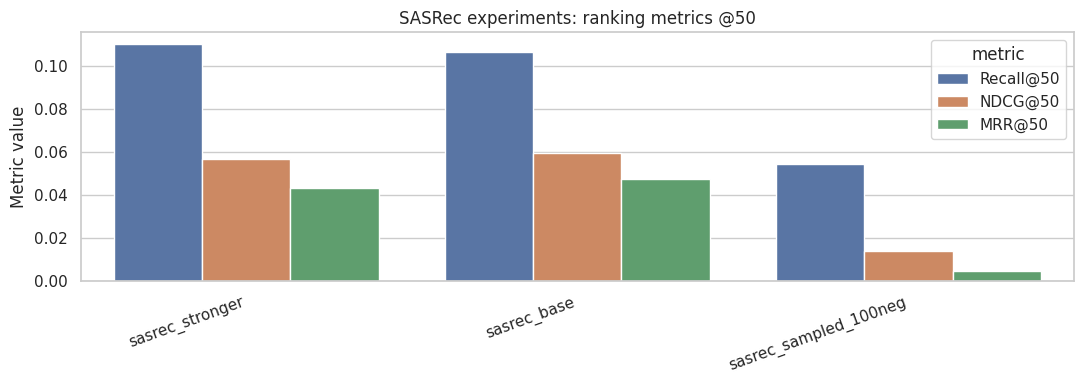

In [ ]:
plt.figure(figsize=(11, 4))

plot_df = sasrec_results_at50.melt(
    id_vars="experiment",
    value_vars=["Recall@50", "NDCG@50", "MRR@50"],
    var_name="metric",
    value_name="value"
)

sns.barplot(data=plot_df, x="experiment", y="value", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.title("SASRec experiments: ranking metrics @50")
plt.xlabel("")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()

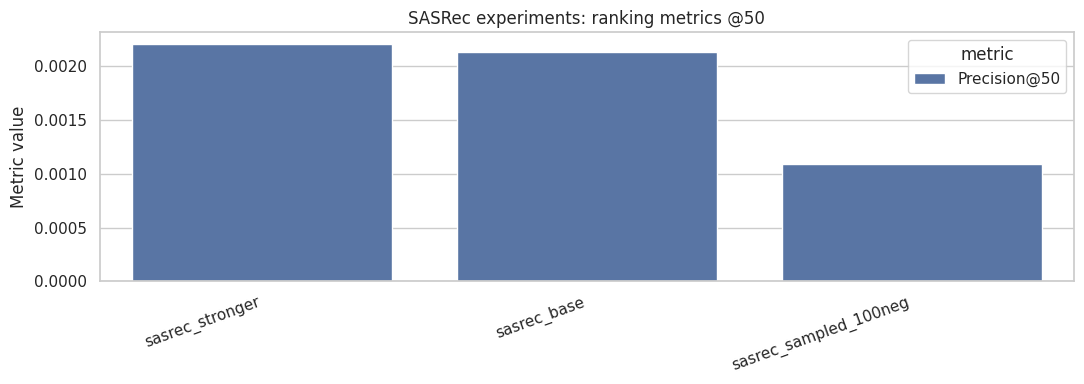

In [ ]:
plt.figure(figsize=(11, 4))

plot_df = sasrec_results_at50.melt(
    id_vars="experiment",
    value_vars=["Precision@50"],
    var_name="metric",
    value_name="value"
)

sns.barplot(data=plot_df, x="experiment", y="value", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.title("SASRec experiments: ranking metrics @50")
plt.xlabel("")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()

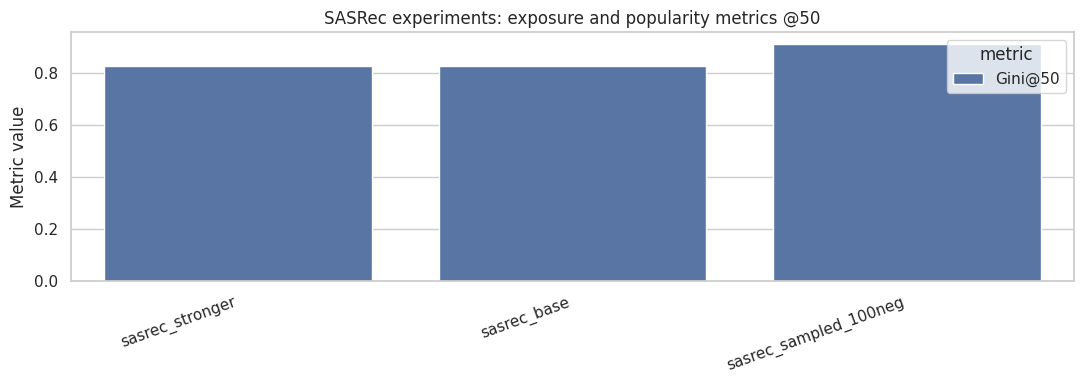

In [ ]:
plt.figure(figsize=(11, 4))

property_plot_df = sasrec_results_at50.melt(
    id_vars="experiment",
    value_vars=["Gini@50"],
    var_name="metric",
    value_name="value"
)

sns.barplot(data=property_plot_df, x="experiment", y="value", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.title("SASRec experiments: exposure and popularity metrics @50")
plt.xlabel("")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()

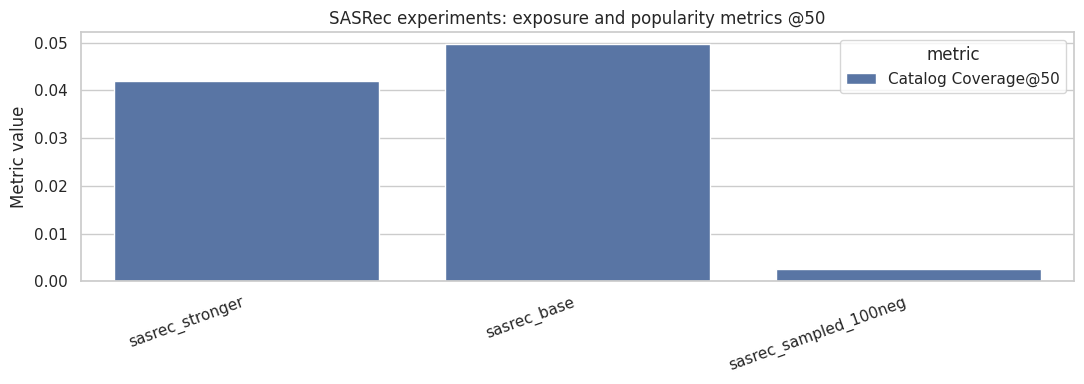

In [ ]:
plt.figure(figsize=(11, 4))

property_plot_df = sasrec_results_at50.melt(
    id_vars="experiment",
    value_vars=["Catalog Coverage@50"],
    var_name="metric",
    value_name="value"
)

sns.barplot(data=property_plot_df, x="experiment", y="value", hue="metric")
plt.xticks(rotation=20, ha="right")
plt.title("SASRec experiments: exposure and popularity metrics @50")
plt.xlabel("")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()

## 11. Сохранение результатов

In [ ]:
output_dir = f"{DATA_DIR}/notebook_3_sasrec_outputs"
os.makedirs(output_dir, exist_ok=True)

split_summary.to_csv(f"{output_dir}/split_summary.csv", index=False)
sasrec_base_history.to_csv(f"{output_dir}/sasrec_base_history.csv", index=False)
sasrec_stronger_history.to_csv(f"{output_dir}/sasrec_stronger_history.csv", index=False)
sasrec_sampled_history.to_csv(f"{output_dir}/sasrec_sampled_history.csv", index=False)

sasrec_accuracy_results_long.to_csv(f"{output_dir}/sasrec_accuracy_results_wide.csv", index=False)
sasrec_accuracy_long.to_csv(f"{output_dir}/sasrec_accuracy_results_long.csv", index=False)
sasrec_property_results.to_csv(f"{output_dir}/sasrec_property_results.csv", index=False)
sasrec_results_long.to_csv(f"{output_dir}/sasrec_results_long.csv", index=False)
sasrec_results_at50.to_csv(f"{output_dir}/sasrec_results_at50.csv", index=False)
sasrec_results_at50.to_csv(f"{output_dir}/sasrec_results.csv", index=False)

item_pop_df.to_csv(f"{output_dir}/item_popularity_reference.csv", index=False)


print("Saved outputs to:", output_dir)

Saved outputs to: /content/drive/MyDrive/Курсовая/final_subsample/notebook_3_sasrec_outputs
